In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input/datasets/ayushdube1316/dddeee/Churn_Modelling.csv'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [17]:
df = pd.read_csv('/kaggle/input/datasets/ayushdube1316/dddeee/Churn_Modelling.csv')

In [18]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [19]:
df.shape

(10000, 14)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [21]:
 df.duplicated().sum()

np.int64(0)

In [22]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [23]:
 df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [24]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [25]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [26]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [27]:
df = pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True,dtype=int)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Age                10000 non-null  int64  
 2   Tenure             10000 non-null  int64  
 3   Balance            10000 non-null  float64
 4   NumOfProducts      10000 non-null  int64  
 5   HasCrCard          10000 non-null  int64  
 6   IsActiveMember     10000 non-null  int64  
 7   EstimatedSalary    10000 non-null  float64
 8   Exited             10000 non-null  int64  
 9   Geography_Germany  10000 non-null  int64  
 10  Geography_Spain    10000 non-null  int64  
 11  Gender_Male        10000 non-null  int64  
dtypes: float64(2), int64(10)
memory usage: 937.6 KB


In [31]:
X = df.drop(columns=["Exited"])
Y = df["Exited"]

In [39]:
from sklearn.model_selection import train_test_split

In [40]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.02,random_state=1)

In [41]:
from sklearn.preprocessing import StandardScaler

In [44]:
scaler = StandardScaler()

In [62]:
# X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [46]:
X_train_scaled

array([[-2.48412375,  1.05724672, -1.04485294, ...,  1.72081273,
        -0.57310845, -1.09421635],
       [ 0.16375631, -0.27789912, -0.69898032, ...,  1.72081273,
        -0.57310845, -1.09421635],
       [-0.1672287 , -0.37326669,  1.72212799, ..., -0.58112076,
         1.74487044, -1.09421635],
       ...,
       [ 0.225816  ,  0.58040892,  1.37625538, ..., -0.58112076,
        -0.57310845, -1.09421635],
       [ 0.13272647,  0.00820356,  1.03038276, ..., -0.58112076,
        -0.57310845, -1.09421635],
       [ 1.16705461,  0.29430624,  0.33863753, ...,  1.72081273,
        -0.57310845,  0.91389605]])

In [48]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [83]:
model = Sequential()

model.add(Dense(11,activation = 'relu',input_dim=11))
model.add(Dense(11,activation = 'relu'))
model.add(Dense(1,activation = 'sigmoid'))


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [84]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [85]:
model.compile(loss='binary_crossentropy',optimizer = 'Adam',metrics=['accuracy'])

In [86]:
history = model.fit(X_train_scaled,Y_train,epochs=100,validation_split=0.2)

Epoch 1/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7430 - loss: 0.5549 - val_accuracy: 0.7959 - val_loss: 0.4892
Epoch 2/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8018 - loss: 0.4492 - val_accuracy: 0.8066 - val_loss: 0.4343
Epoch 3/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8217 - loss: 0.4184 - val_accuracy: 0.8219 - val_loss: 0.4067
Epoch 4/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8318 - loss: 0.4018 - val_accuracy: 0.8337 - val_loss: 0.3880
Epoch 5/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8388 - loss: 0.3889 - val_accuracy: 0.8413 - val_loss: 0.3710
Epoch 6/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8459 - loss: 0.3761 - val_accuracy: 0.8418 - val_loss: 0.3594
Epoch 7/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8520 - loss: 0.3671 - val_accuracy: 0.8505 - val_loss: 0.3498
Epoch 8/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8529 - loss: 0.3602 - val_accu

In [79]:
model.layers[0].get_weights()


[array([[-0.608085  , -0.48040295, -0.09392092, -0.15975417,  0.17074239,
          0.15814112, -0.18496735, -0.29144102,  0.04801646, -0.41556233,
          0.02352422],
        [ 0.32636383,  0.9427513 , -0.15154876, -0.677474  , -0.33302873,
         -0.92083114,  0.37887642, -0.62402487,  0.0783944 ,  0.05390837,
         -0.6298898 ],
        [ 0.70361054,  0.44387922,  0.03723903, -0.04688798, -0.13829659,
         -0.08379895, -0.10201589,  0.22461645,  0.00629083,  0.30337012,
          0.11652198],
        [-0.5969973 , -0.20538323, -0.16516006, -0.03585013,  0.05906611,
          0.00615877,  0.2333835 ,  0.15130413,  0.7031041 , -0.2915913 ,
          0.06857432],
        [ 0.6473681 ,  0.2968158 , -1.3362763 , -0.06198566, -0.22154345,
         -0.11966192,  0.42329955,  0.3249926 ,  0.93915266,  0.90607303,
         -0.02602525],
        [ 0.13150725,  0.18326989, -0.08286329, -0.15331168, -0.21963428,
          0.071578  ,  0.3781652 , -0.62048274,  0.01421885, -0.1997565

In [80]:
y_log = model.predict(X_test_scaled)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [81]:
y_pred= np.where(y_log>0.5,1,0)

In [82]:
from sklearn.metrics import accuracy_score
accuracy_score(Y_test,y_pred)

0.865

In [88]:
import matplotlib.pyplot as plt

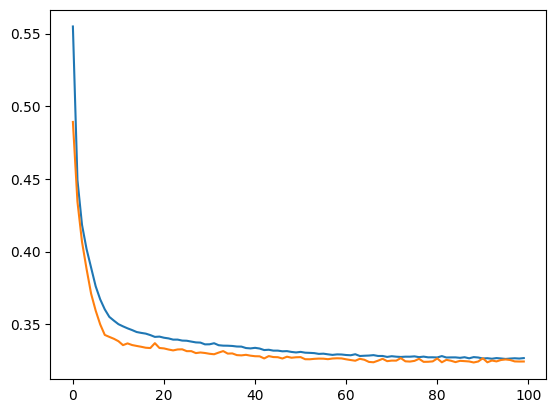

In [90]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

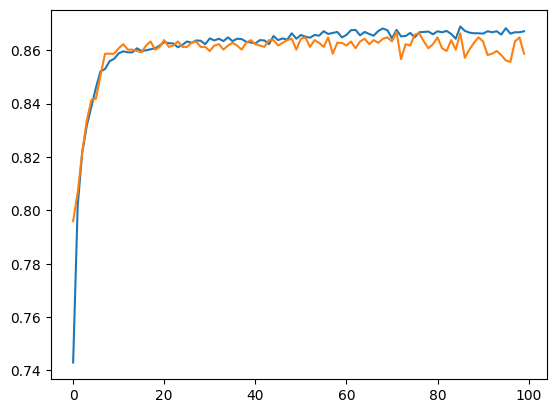

In [91]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])